In [1]:
import json
from itertools import combinations_with_replacement
import numpy as np
import pandas as pd

mapping = {
    "strongly disagree": -1,
    "somewhat disagree": -0.5,
    "neutral": 0,
    "somewhat agree": 0.5,
    "strongly agree": 1
}

def cosine_similarity(vector, vectors):
    vectors = np.asarray(vectors, dtype=float)
    vector = np.asarray(vector, dtype=float)
    dot_products = vectors @ vector
    norms = np.linalg.norm(vectors, axis=1) * np.linalg.norm(vector)
    return dot_products / norms

def rank_types_by_closest_similarity(new_vector, vectors, df):
    # 1. Calculate similarities
    similarities = cosine_similarity(new_vector, vectors)
    
    # 2. Find the index of the single most similar row (the 'closest leader')
    # We use argmax to get the position of the highest similarity score
    best_match_idx = np.argmax(similarities)
    
    # 3. Retrieve the type associated with that specific leader
    # We want a Series of all types, sorted by how close their best representative was
    # This ensures compatibility with your ranking index [0] logic
    
    # Create a temporary series of similarities mapped to types
    temp_df = df.copy()
    temp_df['sim_score'] = similarities
    
    # Group by Type and get the max similarity for each type
    # Then sort so the "closest" type is at the top
    ranking = temp_df.groupby("Type")['sim_score'].max().sort_values(ascending=False)
    
    return ranking

def rank_types_by_weighted_similarity(new_vector, vectors, df):
    cosine_similarities = cosine_similarity(new_vector, vectors)

    type_vectors = {}
    for pokemon_type in df["Type"].unique():
        mask = df["Type"] == pokemon_type
        weights = cosine_similarities[mask]

        if np.sum(weights) == 0:
            type_vectors[pokemon_type] = np.mean(vectors[mask], axis=0)
        else:
            type_vectors[pokemon_type] = np.average(
                vectors[mask], axis=0, weights=weights)

    scores = {pokemon_type: vec.mean()
              for pokemon_type, vec in type_vectors.items()}
    ranking = pd.Series(scores).sort_values(ascending=False)
    return ranking

def rank_types(new_vector, vectors, df, method="weighted"):
    match method:
        case "weighted":
            return rank_types_by_weighted_similarity(new_vector, vectors, df)
        case "closest":
            return rank_types_by_closest_similarity(new_vector, vectors, df)
        case _:
            raise Exception("Invalid method")

def build_results_map(*, df: pd.DataFrame, vectors: np.ndarray, method="weighted") -> dict[str, str]:
    """Build a mapping from answer-vectors -> top-ranked type.

    Kept as a function so importing this module doesn't trigger expensive work.
    """
    all_possible_vectors = list(combinations_with_replacement(mapping.values(), 15))
    all_possible_vectors = [np.array(vector) for vector in all_possible_vectors]

    results_map: dict[str, str] = {}
    for vector in all_possible_vectors:
        key = ",".join(map(str, vector))
        ranking = rank_types(vector, vectors, df, method.lower())
        results_map[key] = str(ranking.index[0])

    return results_map

In [2]:


# Load your reference data here
df = pd.read_csv("/Users/brandonminer/projects/sematic-personality-quiz/api/data/gym_leaders.csv")
vectors = df.drop(columns=["Leader", "Type"]).replace(mapping).to_numpy()

results_map = build_results_map(df=df, vectors=vectors, method="closest")
print(f"Generated {len(results_map)} combinations")


Generated 3876 combinations


/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_91708/4013272486.py:19: RuntimeWarning: invalid value encountered in divide
  return dot_products / norms


/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_91708/4013272486.py:19: RuntimeWarning: invalid value encountered in divide
  return dot_products / norms
/var/folders/09/4h25jfnn06q73576vknj8hz40000gn/T/ipykernel_91708/4013272486.py:19: RuntimeWarning: invalid value encountered in divide
  return dot_products / norms


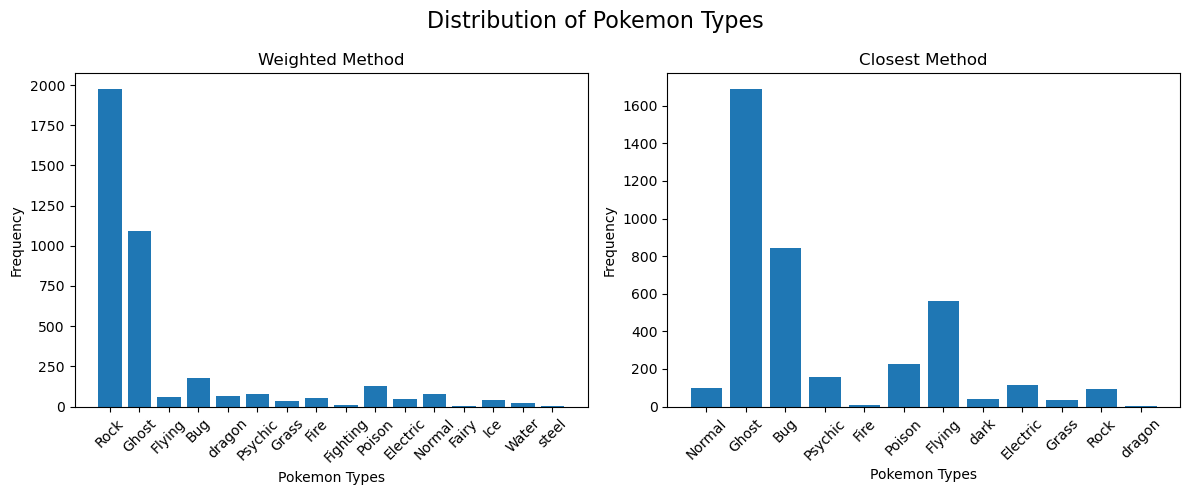

In [17]:
import matplotlib.pyplot as plt
from collections import Counter

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- First Plot (Weighted) ---
results_weighted = list(build_results_map(df=df, vectors=vectors, method="weighted").values())
counts1 = Counter(results_weighted)

# Use keys and values directly from the Counter to ensure they match
ax1.bar(counts1.keys(), counts1.values())
ax1.set_title("Weighted Method")
ax1.tick_params(axis='x', labelrotation=45)

# --- Second Plot (Closest) ---
results_closest = list(build_results_map(df=df, vectors=vectors, method="closest").values())
counts2 = Counter(results_closest)

# Use ax2 here and pass counts2.values() (the numbers)
ax2.bar(counts2.keys(), counts2.values())
ax2.set_title("Closest Method")
ax2.tick_params(axis='x', labelrotation=45)

# --- Global Labels ---
fig.suptitle("Distribution of Pokemon Types", fontsize=16)
for ax in [ax1, ax2]:
    ax.set_xlabel("Pokemon Types")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()